# UC Berkeley Capstone Project -- Data Analysis & Modelling

This is a notebook for my UC Berkeley Capstone project.

I have a harvester script running in GCP that collects YouTube video metadata and metrics and stores that in a BQ table. 
Because the script is running in an ongoing basis, and I have limited time before I need to turn in the project, I am going to start working with synthetic data integrated with my real data, and gradually shift over to all real data.

- This will allow me start modelling sooner. 
- The synthetic data will be identifiable in the DataFrame.
- I will be storing a Parquet snapshot of the BQ data extract + model version in a GCS Bucket, so that I can always see which specific data + model produced which specific results.

The workflow here is:

1. Create a snapshot of the BQ data 
1. Add the synthetic data rows
1. Store the dataset in a versioned GCS bucket
1. (when modelling) store model vesrion data + stats in a versioned GCS bucket as well.

TODO (jelani):

1. make the snapshotting proces easier to manage with a global flag for on/off and constants for the different model version names, video snapshog version names, etc. The on/off can live in each code blcok where it is needed so that I'm not hunting through code to update it. 
1. Have this all live in a cell at the top of the notebook to make it easy to access and change.
1. Add the newer cut of real data
1. Make the label for synth data split easier to figure out (and set some math to do the split)
1. Add RnadomForrest


In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import utils.snapshot_data as snapshot
from utils.snapshot_model import (
    TrainingData, ModelResult, ModelConfig,
    save_model, list_models,
)
from data_processing.data_cleanup import build_clean_dataset
from data_processing.feature_engineering import engineer_features
from data_processing.synthetic_data import generate_synthetic_data, combine_real_and_synthetic


from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, 
    roc_auc_score, 
    confusion_matrix,
    RocCurveDisplay,
)
from xgboost import XGBClassifier




In [3]:
def create_new_snapshot(
    version_name: str, additional_notes: str = ""
):
    """
    Creates snapshots in GCS bucket for:
      - Channel baseline data
      - Channel median data
      - Video snapshot data

    Snapshots can be viewed via `snapshot.list_snapshots` and loaded via
    `snapshot.load_videos` and `snapshot.load_baselines`

    version_name: Name like 'v1.0_real'
    additional_notes: Descriptive notes. `version_name` is automatically added.

    Returns: (video_df, baseline_df, median_df, video_meta, baseline_meta)
    """
    video_df, video_meta = snapshot.snapshot_video_data(version_tag=version_name, 
            notes=f"Video data version {version_name}. {additional_notes}",
    )

    baseline_df, median_df, baseline_meta = snapshot.snapshot_baselines(
        version_tag=version_name,
        notes=f"Channel baselines corresponding to {version_name} video snapshot. {additional_notes}",
    )
    return (video_df, baseline_df, median_df, video_meta, baseline_meta)

In [4]:
# Only run this when creating new versions
#new_version_name = "v2.0_real"
#additional_notes = "More triplet rows from a few additional days."
#video_df, baseline_df, median_df, video_meta, baseline_meta = create_new_snapshot(version_name=new_version_name, additional_notes=additional_notes)

# See what's available
snapshot.list_snapshots()

Found 7 snapshots:

  [baselines] v1.0_model_mixed66  |  28544 baseline videos, 965 medians  |  2026-03-25
              Files: gs://maduros-dolce-capstone-data/snapshots/baselines_v1.0_model_mixed66_28544rows_20260325_035026.parquet
                     gs://maduros-dolce-capstone-data/snapshots/medians_v1.0_model_mixed66_965rows_20260325_035026.parquet

  [baselines] v1.0_real  |  28544 baseline videos, 965 medians  |  2026-03-22
              Files: gs://maduros-dolce-capstone-data/snapshots/baselines_v1.0_real_28544rows_20260322_184459.parquet
                     gs://maduros-dolce-capstone-data/snapshots/medians_v1.0_real_965rows_20260322_184459.parquet

  [baselines] v2.0_real  |  28724 baseline videos, 971 medians  |  2026-03-26
              Files: gs://maduros-dolce-capstone-data/snapshots/baselines_v2.0_real_28724rows_20260326_061729.parquet
                     gs://maduros-dolce-capstone-data/snapshots/medians_v2.0_real_971rows_20260326_061729.parquet

  [videos]    v1.0_m

In [83]:
# Load an existing snapshot (no new version created) when loading this notebook,
# as snapshotted df may not be in memory.
video_data_version = "v2.0_real"
df_videos, meta = snapshot.load_videos(video_data_version)
df_baselines, df_medians, baseline_meta = snapshot.load_baselines(video_data_version)

print(f"Video snapshots: {len(df_videos)}")
print(f"Baseline videos: {len(df_baselines)}")
print(f"Baseline medians: {len(df_medians)}")

df_videos.head()

Loaded snapshot 'v2.0_real': 17345 rows from 2026-03-26
  Polls: {'upload': 6846, '24h': 6428, '7d': 4071}
Loaded baselines 'v2.0_real': 28724 baseline videos, 971 median rows (971 channels)
Video snapshots: 17345
Baseline videos: 28724
Baseline medians: 971


,video_id,poll_timestamp,channel_id,channel_handle,title,view_count,like_count,comment_count,face_count,brightness,...,description,tags,duration_seconds,category_id,category_name,published_at,poll_label,hours_since_publish,subscriber_count,contains_synthetic_media
0,4RR5F-ceOV0,2026-03-25 19:05:05.842541+00:00,UCVfGooMww5Wy6kZhlfw9eKw,@exercisesroutenes,Best Exercises for Bigger Quadriceps Hamstring...,300,40,0,0,100.657784,...,Best Exercises for Bigger Quadriceps Hamstring...,[Best Exercises for Bigger Quadriceps Hamstrin...,168,27,Education,2026-03-25 13:23:02+00:00,upload,5.70,204000,False
1,72y8wkhJnSQ,2026-03-25 19:05:05.842541+00:00,UCE4SUtMzQPShBeYtTczmODw,@worlddhistory,"Kim Jong-un, Putin and his friend Lukashenko ...",390,28,1,0,71.422321,...,"Kim Jong-un, Vladimir Putin and his friend Ale...","[kim jong un, shorts, viral, belarus, russia, ...",25,22,People & Blogs,2026-03-25 17:03:00+00:00,upload,2.03,391000,False
2,dwDdCFZYg8o,2026-03-25 19:05:05.842541+00:00,UCrz8eKN6LOmktwJ0xY605WQ,@star-bean,She brought me real plants and peacock feather...,796,9,0,0,69.745394,...,,[],38,24,Entertainment,2026-03-25 14:16:52+00:00,upload,4.80,404000,False
3,xWfAsrubbp8,2026-03-25 19:05:05.842541+00:00,UChUJK8SpPya6KBML3bo_YFg,@journeywithharshfitness,25 March 2026,365,3,0,1,36.700382,...,,[],29,17,Sports,2026-03-25 17:22:13+00:00,upload,1.71,1920,False
4,4CP5IIROw48,2026-03-25 19:05:05.842541+00:00,UC1rIOwTqDuWkFj87HZYRFOg,@nytcooking,Seems like these #supermariobros have been doi...,394,6,0,1,69.026418,...,------------------------------------------\n\n...,"[cooking, cooks, recipes, recipe, how-to, how ...",25,26,Howto & Style,2026-03-25 18:49:08+00:00,upload,0.27,1260000,False


In [64]:
df_baselines.head()

,channel_id,channel_handle,vertical,tier,video_id,title,published_at,duration_seconds,category_id,category_name,view_count,like_count,comment_count,subscriber_count,baseline_polled_at
0,UCkw4JCwteGrDHIsyIIKo4tQ,@edurekain,Tech,L,WxE7elJuyt0,AI Agent Full Course For Beginners 2026 | AI ...,2026-03-18 12:21:25+00:00,26377,27,Education,11736,429,0,4440000,2026-03-25 04:01:15.568735+00:00
1,UCkw4JCwteGrDHIsyIIKo4tQ,@edurekain,Tech,L,_WcSO1BE7To,Machine Learning Full Course - Learn Machine L...,2026-03-17 18:14:12+00:00,39065,27,Education,5450,149,0,4440000,2026-03-25 04:01:15.568735+00:00
2,UCkw4JCwteGrDHIsyIIKo4tQ,@edurekain,Tech,L,4cExalx09xU,Data Science Full Course - Learn Data Science ...,2026-03-13 15:36:48+00:00,39652,27,Education,4879,191,0,4440000,2026-03-25 04:01:15.568735+00:00
3,UCkw4JCwteGrDHIsyIIKo4tQ,@edurekain,Tech,L,1Qm_RgejEHg,AI & ML Full Course 2026 | Complete Artificial...,2026-03-12 17:16:46+00:00,42900,27,Education,23345,631,1,4440000,2026-03-25 04:01:15.568735+00:00
4,UCkw4JCwteGrDHIsyIIKo4tQ,@edurekain,Tech,L,vbpQbryiLO8,MLOps Full Course for [2026] -12 hour | MLOps ...,2026-03-11 16:48:40+00:00,41455,27,Education,5817,166,1,4440000,2026-03-25 04:01:15.568735+00:00


In [65]:
df_medians.head()

,channel_id,channel_handle,baseline_video_count,median_views,median_likes,median_comments,median_engagement_rate
0,UCkw4JCwteGrDHIsyIIKo4tQ,@edurekain,30,9614,261,1,0.027339
1,UCqOLFDSLrYKJUuSS0tQqvcw,@guptainformationsystem,30,39977,1517,98,0.040854
2,UCnEdfCdbxJJ9ouWKLSRCRRw,@samsungus,30,1279,30,1,0.020794
3,UCs6nmQViDpUw0nuIx9c_WvA,@programmingknowledge,30,5319,67,5,0.015694
4,UC29ju8bIPH5as8OGnQzwJyA,@traversymedia,30,50462,2239,132,0.046096


In [43]:
print(df_videos.describe())

print(df_videos.info())

          view_count   like_count  comment_count  face_count    brightness  \
count        12990.0      12990.0        12990.0     12990.0  12990.000000   
mean    34021.219861  1227.828253      63.344958    0.837028     76.848276   
std    323371.786035  6341.310058     282.284115    1.007096     28.045903   
min              0.0          0.0            0.0         0.0      0.000000   
25%            241.0         10.0            0.0         0.0     58.422690   
50%           1462.0         68.0            4.0         1.0     74.795700   
75%          9286.25        425.0           25.0         1.0     92.240245   
max       25826937.0     304343.0         9608.0        14.0    212.109184   

       colorfulness  duration_seconds  hours_since_publish  subscriber_count  
count  12990.000000           12990.0         12990.000000           12990.0  
mean      42.168769       1074.778984            41.332661    1469237.938414  
std       23.492837       2504.765361            74.938334  

In [44]:
# Initial cleaning

# NULL value in contains_synthetic_media means that the video couldn't be asssessed (e.g. private or deleted).
# execlude those
df_videos.dropna(subset=["contains_synthetic_media"], inplace=True)

# Build the df with baseline metrics inlined 
df_clean = build_clean_dataset(df_videos, df_medians)
df_model = engineer_features(df_clean)

print(df_model.head())

Building clean dataset

[1/3] Pivoting snapshots...
  Videos with all 3 polls: 2562 (dropped 2677 incomplete)
  Pivoted shape: (2625, 34)

[2/3] Joining baseline medians...
  Baseline join: 2625/2625 videos matched a channel median

[3/3] Cleaning data...
  Cleaned: 2625 rows × 40 columns

Clean dataset: 2625 rows × 40 columns
Engineering features

[1/7] Computing target variable...
  Target distribution: 56.5% above baseline, 43.5% below

[2/7] Computing velocity features...
  Computed velocity for: ['view_count', 'like_count', 'comment_count', 'subscriber_count']

[3/7] Computing subscriber-normalized metrics...
  Computed subscriber-normalized metrics for upload/24h/7d

[4/7] Computing categorical features...
  Title categories:
title_category
neutral        1708
all_caps        262
exclamation     259
question        237
listicle         85
how_to           38
clickbait        30
emoji_heavy       6
  Description categories:
desc_category
link_heavy        719
has_links         630

In [45]:
def get_synth_rows_proportion(num_real_rows: int, target_real_pct: float):
    return math.floor(float(num_real_rows) / target_real_pct) - num_real_rows

In [66]:
target_synth_rows = get_synth_rows_proportion(num_real_rows=len(df_model), target_real_pct=0.7)
print(f"target_synth_rows: {target_synth_rows}")

# Generate synthetic rows (baselines from real channels)
df_synth = generate_synthetic_data(df_model, num_rows=target_synth_rows, seed=42)

# Combine
df_combined = combine_real_and_synthetic(df_model, df_synth)

df_combined.sample(8)

target_synth_rows: 1125
Generating 1125 synthetic rows

[1/5] Preparing data for synthesis...
  Input shape: (2625, 22)

[2/5] Fitting GaussianCopulaSynthesizer...


/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/site-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/site-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


  Fit complete

[3/5] Sampling synthetic rows...
  Generated 1125 rows

[4/5] Assigning real channels and baselines...
  Assigned 1125 synthetic rows to 344 real channels
  Baseline match: 1125/1125

[5/5] Postprocessing and recomputing features...

Synthetic data: 1125 rows
Assigned to 344 real channels
Target balance: {1: 602, 0: 523}
Combined dataset: 3750 rows (2625 real + 1125 synthetic, 30% synthetic)


/Users/jelanigould-bailey/Desktop/uc_berkeley_capstone_repo/repo/data_processing/synthetic_data.py:350: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_combined = pd.concat(
/Users/jelanigould-bailey/Desktop/uc_berkeley_capstone_repo/repo/data_processing/synthetic_data.py:350: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_combined = pd.concat(


,video_id,channel_id,channel_handle,title,description,tags,duration_seconds,category_id,category_name,published_at,...,desc_link_count,desc_hashtag_count,tag_count,has_tags,publish_hour,publish_dayofweek,publish_is_weekend,is_short,duration_minutes,contains_synthetic_data
2148,v6WQTMfNZ2M,UC20sXo8ReewkzNKBFgzVCPA,@tamiltechofficial,🗺️ Google Map-ன் 3 அட்டகாசமான Feature 🔥- Long ...,Google introduced AI Features into the Google ...,[],74,28,Science & Technology,2026-03-15 04:30:30+00:00,...,11,13,0,0,4,6,1,0,1.233333,False
1044,uwq4cSdEJgo,UCrUyInvjmniSK3gBzXjB5qg,@jamirayvintage,Goodwill Bins & $20 Facebook Marketplace Antiq...,,[],1266,26,Howto & Style,2026-03-09 22:02:28+00:00,...,0,0,0,0,22,0,0,0,21.1,False
3318,syn-000693,UC8-9mdGBP5dtxEKJM2E9bHA,@workout4d,[Synthetic],[Synthetic],[],6,24,Synthetic,NaT,...,0,0,0,0,0,0,0,1,0.1,True
439,WdAIkB8ACTQ,UCRP5p2RfxJgnKyWgve5pJ-Q,@canalhistory,O Livro Que Transformou Donald Trump Em Um Fen...,Antes de se tornar uma das figuras mais conhec...,[],595,24,Entertainment,2026-03-13 17:30:00+00:00,...,5,1,0,0,17,4,0,0,9.916667,False
3515,syn-000890,UC-pznwpRTZn7Lfx53BRQv0g,@epomaker,[Synthetic],[Synthetic],[],1298,22,Synthetic,NaT,...,0,0,0,0,0,0,0,0,21.633333,True
1849,-L8Ov4drqVc,UCsP4e_ss5al2JrKPe15wb6w,@sanjayyadav-jt4tb,Welcome to my YouTube live❤️,#youtube #trending #entertainment #subscribe #...,[],945,22,People & Blogs,2026-03-09 16:45:06+00:00,...,0,13,0,0,16,0,0,0,15.75,False
93,ftfZ7m8YK0w,UCMzdJtCZPlFRLgwI6I7UFEQ,@anishavlog607,Aaj Sehri Karne Bahar Gaye✨Sehri Mini Vlog❤️🌙|...,Aaj Sehri Karne Bahar Gaye✨Sehri Mini Vlog❤️🌙|...,[],56,22,People & Blogs,2026-03-09 00:14:22+00:00,...,0,5,0,0,0,0,0,1,0.933333,False
1281,uCwRvd9N2ic,UCiKNvzMjBFowg5Sj6pevymA,@metapcs,BUILDING TWO MEGA CUSTOMS LIVE! RATING YOUR SE...,Support the stream: https://streamlabs.com/met...,[],0,20,Gaming,2026-03-13 17:00:22+00:00,...,1,0,0,0,17,4,0,1,0.0,False


In [ ]:
final_data_version_name = "v2.0_mixed_70real"

# Only need to run when there is new base data to snapsho
"""
notes = "2625 real + 1125 synthetic (GaussianCopula seed=42), real channel baselines"
snapshot_meta = snapshot.save_snapshot(
    df=df_combined, version_tag=final_data_version_name, notes=notes
)
"""

# Use this to load so aren't creating a snapshot everytime you execute the notebook
df_combined, _ = snapshot.load_videos(final_data_version_name)

df_train = df_combined

# never evaluate on synthetic data):
df_eval = df_combined[~df_combined["contains_synthetic_data"]]

df_train.sample(5)


--- Snapshot v2.0_mixed_70real ---
  Rows: 3750 (2625 real, 1125 synthetic)
  Polls: {}
  GCS: gs://maduros-dolce-capstone-data/snapshots/snapshots_v2.0_mixed_70real_3750rows_20260326_075206.parquet
Loaded snapshot 'v2.0_mixed_70real': 5812 rows from 2026-03-26
  Polls: {}


,video_id,channel_id,channel_handle,title,description,tags,duration_seconds,category_id,category_name,published_at,...,desc_link_count,desc_hashtag_count,tag_count,has_tags,publish_hour,publish_dayofweek,publish_is_weekend,is_short,duration_minutes,contains_synthetic_data
119,wbCGaKd9_yQ,UCESLZhusAkFfsNsApnjF_Cg,@allin,Chamath Explains Why AI is So Unpopular: Terri...,Follow the besties: \nhttps://x.com/chamath\nh...,[],110,24,Entertainment,2026-03-16 01:43:46+00:00,...,11,3,0,0,1,0,0,0,1.833333,False
1149,zKg3KgRQWWs,UC7HhSlh-QbL9626A_mM4DRg,@englishlanguageacademy.,القراءة وتحسين مهارة النطق باللغة الإنجليزية👌🫵...,All rights reserved\nجميع الحقوق محفوظة.\nجميع...,[],668,27,Education,2026-03-08 15:45:27+00:00,...,0,0,0,0,15,6,1,0,11.133333,False
2322,Y_E8fejmyhM,UC1rIOwTqDuWkFj87HZYRFOg,@nytcooking,Watch the Gyllenhaal siblings bake their famil...,,[],40,26,Howto & Style,2026-03-13 18:34:10+00:00,...,0,0,0,0,18,4,0,1,0.666667,False
2083,ke2u3_XcvFk,UCiKNvzMjBFowg5Sj6pevymA,@metapcs,Why Did My Windows Key Disappear?!,,[],68,28,Science & Technology,2026-03-11 15:01:25+00:00,...,0,0,0,0,15,2,0,0,1.133333,False
5565,syn-001496,UC4zvoRyq36u8BZr_lYdu64A,@satyawadidebate,[Synthetic],[Synthetic],[],310,22,Synthetic,NaT,...,0,0,0,0,0,0,0,0,5.166667,True


In [68]:
# --- Define feature columns (exclude IDs, text, timestamps, target, metadata) ---

# Add 7d metric columns to the exclusion list
EXCLUDE_7D = [c for c in df_combined.columns if c.endswith('_7d')]
print(f"Excluding 7d features: {EXCLUDE_7D}")

EXCLUDE_COLS = [
    # IDs and text
    'video_id', 'channel_id', 'channel_handle', 'title', 'description', 'tags',
    'category_id', 'category_name',
    # Timestamps
    'published_at', 'poll_timestamp_upload', 'poll_timestamp_24h', 'poll_timestamp_7d',
    # Target and intermediate
    'above_baseline', 'engagement_7d', 'baseline_engagement',
    # Metadata flags
    'contains_synthetic_data', 'contains_synthetic_media',
    # Baseline raw (already captured in baseline_engagement)
    'baseline_channel_handle', 'baseline_video_count',
    'baseline_median_views', 'baseline_median_likes',
    'baseline_median_comments', 'baseline_median_engagement_rate',
    # Categorical groupings (use the encoded versions instead)
    'vertical', 'tier',
]

EXCLUDE_COLS.extend(EXCLUDE_7D)

feature_cols = [c for c in df_combined.columns if c not in EXCLUDE_COLS]
print(f"\nFeature columns ({len(feature_cols)}):")
print(feature_cols)


Excluding 7d features: ['view_count_7d', 'like_count_7d', 'comment_count_7d', 'subscriber_count_7d', 'hours_since_publish_7d', 'poll_timestamp_7d', 'engagement_7d', 'views_per_sub_7d', 'likes_per_sub_7d', 'comments_per_sub_7d']

Feature columns (39):
['duration_seconds', 'face_count', 'brightness', 'colorfulness', 'view_count_upload', 'like_count_upload', 'comment_count_upload', 'subscriber_count_upload', 'hours_since_publish_upload', 'view_count_24h', 'like_count_24h', 'comment_count_24h', 'subscriber_count_24h', 'hours_since_publish_24h', 'baseline_baseline_video_count', 'view_count_velocity_24h', 'like_count_velocity_24h', 'comment_count_velocity_24h', 'subscriber_count_velocity_24h', 'views_per_sub_upload', 'likes_per_sub_upload', 'comments_per_sub_upload', 'views_per_sub_24h', 'likes_per_sub_24h', 'comments_per_sub_24h', 'title_category', 'desc_category', 'title_length', 'title_word_count', 'desc_length', 'desc_link_count', 'desc_hashtag_count', 'tag_count', 'has_tags', 'publish_h

In [70]:
# === Split: real data only for evaluation ===

df_real = df_combined[~df_combined['contains_synthetic_data']].copy()
df_synth_rows = df_combined[df_combined['contains_synthetic_data']].copy()

print(f"Real rows:      {len(df_real)}")
print(f"Synthetic rows: {len(df_synth_rows)}")

# Split real data into train/test (stratified on target)
X_real = df_real[feature_cols]
y_real = df_real['above_baseline']

X_real_train, X_test, y_real_train, y_test = train_test_split(
    X_real, y_real,
    test_size=0.2,
    random_state=42,
    stratify=y_real,
)

# Add synthetic rows to training set only
X_synth = df_synth_rows[feature_cols]
y_synth = df_synth_rows['above_baseline']

X_train = pd.concat([X_real_train, X_synth], ignore_index=True)
y_train = pd.concat([y_real_train, y_synth], ignore_index=True)

# Handle NaN/inf
X_train = X_train.fillna(0).replace([np.inf, -np.inf], 0)
X_test = X_test.fillna(0).replace([np.inf, -np.inf], 0)

print(f"\nTraining set: {len(X_train)} rows "
      f"({len(X_real_train)} real + {len(X_synth)} synthetic)")
print(f"Test set:     {len(X_test)} rows (100% real)")
print(f"\nTarget balance (train): {y_train.value_counts().to_dict()}")
print(f"Target balance (test):  {y_test.value_counts().to_dict()}")

# Scale for LR (RF and XGBoost use unscaled)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Real rows:      4069
Synthetic rows: 1743

Training set: 4998 rows (3255 real + 1743 synthetic)
Test set:     814 rows (100% real)

Target balance (train): {1: 2792, 0: 2206}
Target balance (test):  {1: 458, 0: 356}


In [71]:
# === Model 1: Logistic Regression with L1 (LASSO) ===

model_lr = LogisticRegression(
    penalty='l1',
    solver='saga',       # supports L1
    C=1.0,               # inverse regularization strength
    max_iter=5000,
    random_state=42,
)
model_lr.fit(X_train_scaled, y_train)

# Predictions on real-only test set
y_pred = model_lr.predict(X_test_scaled)
y_pred_proba = model_lr.predict_proba(X_test_scaled)[:, 1]

print("=" * 60)
print("Logistic Regression (L1) — Evaluated on Real Data Only")
print("=" * 60)
print(f"\nROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Below Baseline', 'Above Baseline'])}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

Logistic Regression (L1) — Evaluated on Real Data Only

ROC-AUC: 0.6464

                precision    recall  f1-score   support

Below Baseline       0.59      0.43      0.50       356
Above Baseline       0.64      0.77      0.70       458

      accuracy                           0.62       814
     macro avg       0.62      0.60      0.60       814
  weighted avg       0.62      0.62      0.61       814

Confusion Matrix:
[[154 202]
 [105 353]]


In [72]:
# === Feature Importance (L1 coefficients) ===

coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': model_lr.coef_[0],
    'abs_coefficient': np.abs(model_lr.coef_[0]),
}).sort_values('abs_coefficient', ascending=False)

# Features that L1 zeroed out (not useful)
zeroed = coef_df[coef_df['coefficient'] == 0]
print(f"Features zeroed out by L1: {len(zeroed)}/{len(coef_df)}")

# Top 20 most important
print("\nTop 20 Features:")
print(coef_df.head(20).to_string(index=False))

Features zeroed out by L1: 2/39

Top 20 Features:
                      feature  coefficient  abs_coefficient
               view_count_24h    -1.605701         1.605701
               like_count_24h     1.086448         1.086448
            likes_per_sub_24h     0.761791         0.761791
      subscriber_count_upload    -0.708324         0.708324
         subscriber_count_24h     0.676819         0.676819
         likes_per_sub_upload     0.535514         0.535514
         views_per_sub_upload    -0.495353         0.495353
            views_per_sub_24h    -0.381900         0.381900
            comment_count_24h     0.299635         0.299635
      comments_per_sub_upload    -0.274526         0.274526
                     is_short    -0.270373         0.270373
baseline_baseline_video_count     0.232086         0.232086
             title_word_count    -0.177499         0.177499
            like_count_upload    -0.174846         0.174846
                 title_length     0.151155        

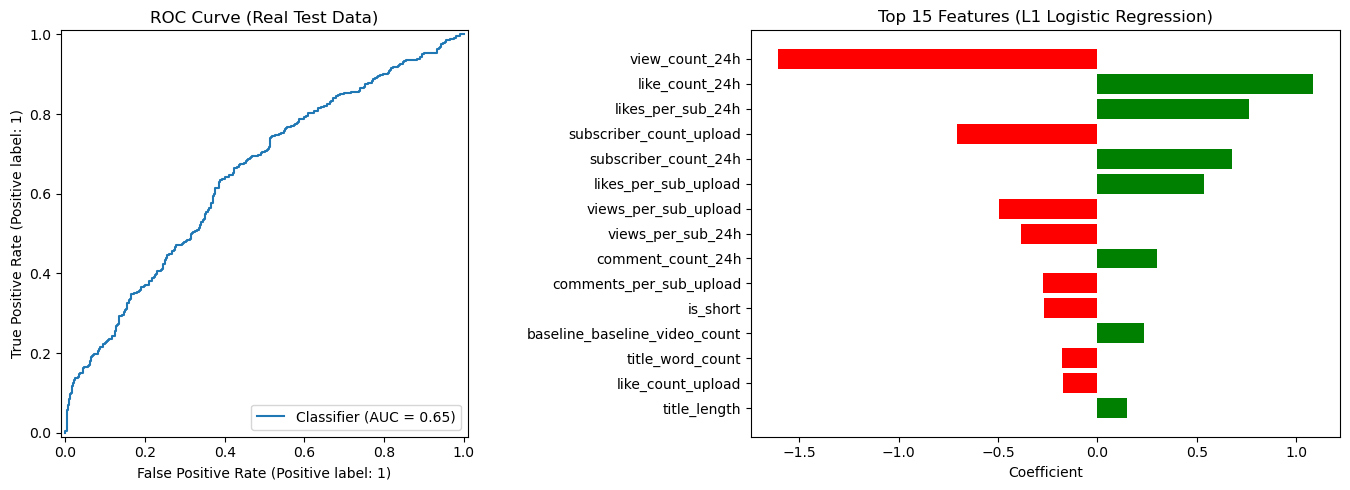

In [73]:
# === Visualizations ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[0])
axes[0].set_title('ROC Curve (Real Test Data)')

# Top 15 feature coefficients
top_15 = coef_df.head(15)
colors = ['green' if c > 0 else 'red' for c in top_15['coefficient']]
axes[1].barh(top_15['feature'], top_15['coefficient'], color=colors)
axes[1].set_xlabel('Coefficient')
axes[1].set_title('Top 15 Features (L1 Logistic Regression)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [74]:
# No scaling needed for RF (tree-based, scale-invariant)
model_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)
model_rf.fit(X_train, y_train)  # unscaled features

# Predictions on real-only test set
y_pred_rf = model_rf.predict(X_test)
y_pred_proba_rf = model_rf.predict_proba(X_test)[:, 1]

print("=" * 60)
print("Random Forest — Evaluated on Real Data Only")
print("=" * 60)
print(f"\nROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
print(f"\n{classification_report(y_test, y_pred_rf, target_names=['Below Baseline', 'Above Baseline'])}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_rf)}")

Random Forest — Evaluated on Real Data Only

ROC-AUC: 0.7966

                precision    recall  f1-score   support

Below Baseline       0.74      0.61      0.67       356
Above Baseline       0.73      0.83      0.78       458

      accuracy                           0.73       814
     macro avg       0.73      0.72      0.72       814
  weighted avg       0.73      0.73      0.73       814

Confusion Matrix:
[[217 139]
 [ 78 380]]


In [76]:
# === RF Feature Importance ===

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_rf.feature_importances_,
}).sort_values('importance', ascending=False)

print("Top 20 Features (Random Forest):")
print(importance_df.head(20).to_string(index=False))

Top 20 Features (Random Forest):
                   feature  importance
            view_count_24h    0.076736
   view_count_velocity_24h    0.067673
            like_count_24h    0.062669
         likes_per_sub_24h    0.061284
         views_per_sub_24h    0.060313
   like_count_velocity_24h    0.053466
         view_count_upload    0.040295
          duration_minutes    0.035765
          duration_seconds    0.035605
      views_per_sub_upload    0.035186
      likes_per_sub_upload    0.033067
         like_count_upload    0.030025
      comments_per_sub_24h    0.028845
      subscriber_count_24h    0.027696
   subscriber_count_upload    0.027473
              colorfulness    0.026917
                brightness    0.026657
hours_since_publish_upload    0.026383
comment_count_velocity_24h    0.025151
   hours_since_publish_24h    0.024906


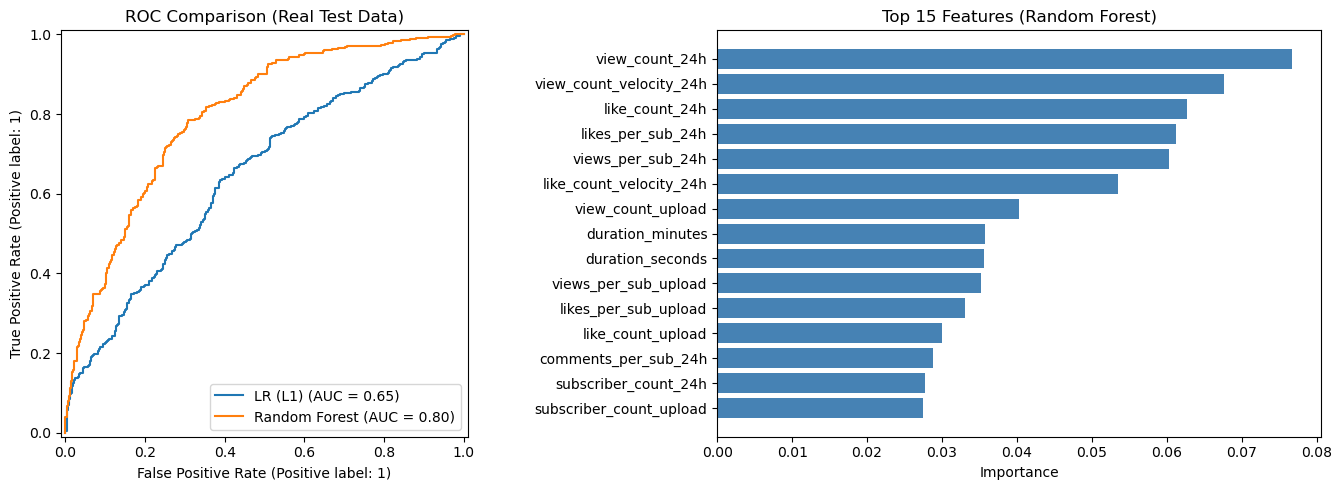

In [77]:
# === Side-by-side comparison ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves compared
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[0], name='LR (L1)')
RocCurveDisplay.from_predictions(y_test, y_pred_proba_rf, ax=axes[0], name='Random Forest')
axes[0].set_title('ROC Comparison (Real Test Data)')

# RF top 15 feature importances
top_15_rf = importance_df.head(15)
axes[1].barh(top_15_rf['feature'], top_15_rf['importance'], color='steelblue')
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 15 Features (Random Forest)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [78]:
# === Model 3: XGBoost ===

model_xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
)
model_xgb.fit(X_train, y_train)  # unscaled, like RF

# Predictions on real-only test set
y_pred_xgb = model_xgb.predict(X_test)
y_pred_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

print("=" * 60)
print("XGBoost — Evaluated on Real Data Only")
print("=" * 60)
print(f"\nROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")
print(f"\n{classification_report(y_test, y_pred_xgb, target_names=['Below Baseline', 'Above Baseline'])}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_xgb)}")

XGBoost — Evaluated on Real Data Only

ROC-AUC: 0.7971

                precision    recall  f1-score   support

Below Baseline       0.71      0.64      0.67       356
Above Baseline       0.74      0.80      0.77       458

      accuracy                           0.73       814
     macro avg       0.73      0.72      0.72       814
  weighted avg       0.73      0.73      0.73       814

Confusion Matrix:
[[228 128]
 [ 92 366]]


In [79]:
# === XGBoost Feature Importance ===

importance_df_xgb = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_xgb.feature_importances_,
}).sort_values('importance', ascending=False)

print("Top 20 Features (XGBoost):")
print(importance_df_xgb.head(20).to_string(index=False))

Top 20 Features (XGBoost):
                      feature  importance
               like_count_24h    0.051958
                     is_short    0.048324
               view_count_24h    0.047435
            likes_per_sub_24h    0.038305
      like_count_velocity_24h    0.037982
            views_per_sub_24h    0.037785
baseline_baseline_video_count    0.034531
            comment_count_24h    0.034431
               title_category    0.033184
      view_count_velocity_24h    0.032349
           desc_hashtag_count    0.028563
             duration_minutes    0.028306
             duration_seconds    0.026326
         comments_per_sub_24h    0.025379
                  desc_length    0.025310
   comment_count_velocity_24h    0.025309
         subscriber_count_24h    0.024964
                 publish_hour    0.024613
            like_count_upload    0.024470
            view_count_upload    0.023937


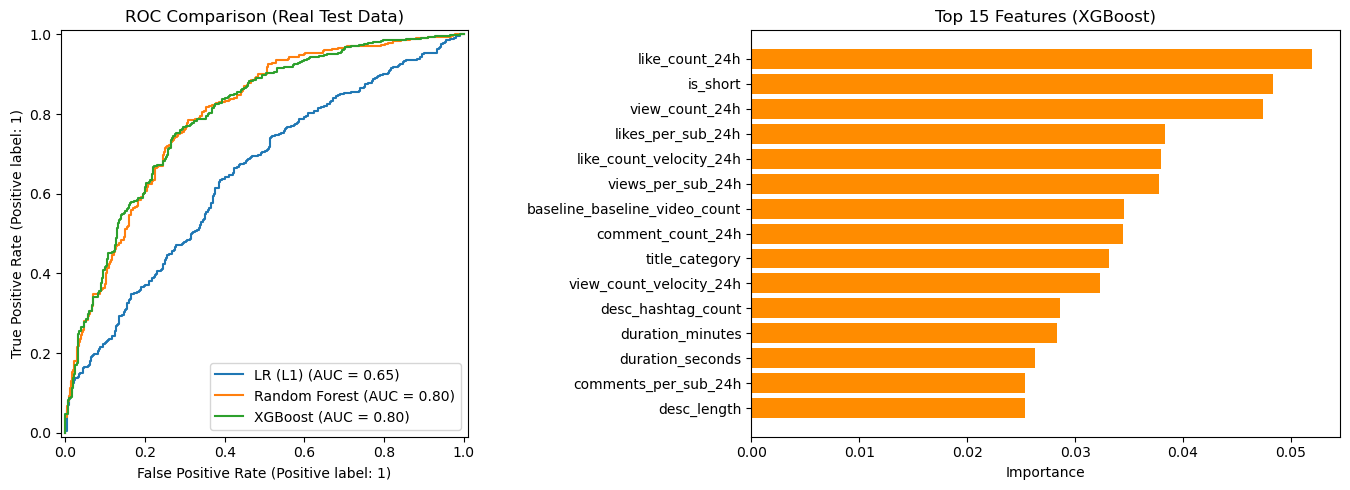

In [80]:
# === All three models compared ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[0], name='LR (L1)')
RocCurveDisplay.from_predictions(y_test, y_pred_proba_rf, ax=axes[0], name='Random Forest')
RocCurveDisplay.from_predictions(y_test, y_pred_proba_xgb, ax=axes[0], name='XGBoost')
axes[0].set_title('ROC Comparison (Real Test Data)')

top_15_xgb = importance_df_xgb.head(15)
axes[1].barh(top_15_xgb['feature'], top_15_xgb['importance'], color='darkorange')
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 15 Features (XGBoost)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# Run this when creating a new model & results snapshot

training_data = TrainingData.from_splits(X_train, y_train, X_test, y_test, X_synth)

# UPDATE NAME BEFORE RUNNING!
model_version = "v2.0"


"""
# Save LogisticRegression Model Results
result_lr = ModelResult.from_sklearn(model_lr, X_test_scaled, y_test, feature_cols)
config_lr = ModelConfig.from_model(model_lr)  # auto-detects LogisticRegression
save_model(
    model=model_lr,
    scaler=scaler,
    feature_cols=feature_cols,
    version_tag=f"{model_version}_lr_l1",
    data_snapshot_tag=f"{final_data_version_name}",
    training_data=training_data,
    result=result_lr,
    config=config_lr,
    notes="Clean LR baseline, all 7d features excluded",
)

# Save RandomForreset Model Results
result_rf = ModelResult.from_sklearn(model_rf, X_test, y_test, feature_cols)
config_rf = ModelConfig.from_model(model_rf)

save_model(
    model=model_rf,
    scaler=None,
    feature_cols=feature_cols,
    version_tag=f"{model_version}_rf",
    data_snapshot_tag=f"{final_data_version_name}",
    training_data=training_data,
    result=result_rf,
    config=config_rf,
    notes="Random Forest, unscaled features, same split as v1.0_lr_l1",
)

# Save XGBoost Model Results
result_xgb = ModelResult.from_sklearn(model_xgb, X_test, y_test, feature_cols)
config_xgb = ModelConfig.from_model(model_xgb)

save_model(
    model=model_xgb,
    scaler=None,
    feature_cols=feature_cols,
    version_tag=f"{model_version}_xgb",
    data_snapshot_tag=f"{final_data_version_name}",
    training_data=training_data,
    result=result_xgb,
    config=config_xgb,
    notes="XGBoost, unscaled features, same split as v1.0_lr_l1",
)
"""

# Compare all saved models
list_models()


Model artifacts saved to models/v2.0_lr_l1/
  Uploaded gs://maduros-dolce-capstone-data/models/v2.0_lr_l1/model.pkl
  Uploaded gs://maduros-dolce-capstone-data/models/v2.0_lr_l1/scaler.pkl
  Uploaded gs://maduros-dolce-capstone-data/models/v2.0_lr_l1/feature_cols.json
  Uploaded gs://maduros-dolce-capstone-data/models/v2.0_lr_l1/metadata.json

Model v2.0_lr_l1 (LogisticRegression)
  Data: v2.0_mixed_70real (3255 real + 1743 synthetic)
  ROC-AUC: 0.6464
  Accuracy: 0.6229
  F1 (above): 0.6969
Model artifacts saved to models/v2.0_rf/
  Uploaded gs://maduros-dolce-capstone-data/models/v2.0_rf/model.pkl
  Uploaded gs://maduros-dolce-capstone-data/models/v2.0_rf/scaler.pkl
  Uploaded gs://maduros-dolce-capstone-data/models/v2.0_rf/feature_cols.json
  Uploaded gs://maduros-dolce-capstone-data/models/v2.0_rf/metadata.json

Model v2.0_rf (RandomForest)
  Data: v2.0_mixed_70real (3255 real + 1743 synthetic)
  ROC-AUC: 0.7966
  Accuracy: 0.7334
  F1 (above): 0.7779
Model artifacts saved to model

In [82]:
# Debugging
snapshot.list_snapshots()

# Compare all saved models
list_models()

Found 9 snapshots:

  [baselines] v1.0_model_mixed66  |  28544 baseline videos, 965 medians  |  2026-03-25
              Files: gs://maduros-dolce-capstone-data/snapshots/baselines_v1.0_model_mixed66_28544rows_20260325_035026.parquet
                     gs://maduros-dolce-capstone-data/snapshots/medians_v1.0_model_mixed66_965rows_20260325_035026.parquet

  [baselines] v1.0_real  |  28544 baseline videos, 965 medians  |  2026-03-22
              Files: gs://maduros-dolce-capstone-data/snapshots/baselines_v1.0_real_28544rows_20260322_184459.parquet
                     gs://maduros-dolce-capstone-data/snapshots/medians_v1.0_real_965rows_20260322_184459.parquet

  [baselines] v2.0_real  |  28724 baseline videos, 971 medians  |  2026-03-26
              Files: gs://maduros-dolce-capstone-data/snapshots/baselines_v2.0_real_28724rows_20260326_061729.parquet
                     gs://maduros-dolce-capstone-data/snapshots/medians_v2.0_real_971rows_20260326_061729.parquet

  [videos]    v1.0_m